- Introduction

The Project: The objective of this project is to define the "best" neighborhood in Pittsburgh using a data-driven approach. We define "best" through the lens of "Health & Safety", with my submetric being "Obesity Rates". A great neighborhood should empower its residents to live long, healthy lives. We initially considered metrics like total population density or the number of census tracts, but these didn't reflect the quality of life. I decided on "Obesity Rates" since it effectively summarizes various factors—walkability, access to fresh food, and community safety—into one measurable percentage.

- The Metric Description

My metric is the Average Obesity Rate per Neighborhood. The dataset provided estimated percentage of the population in different neighborhoods in Allegheny county that were considered obese. Because neighborhoods consist of multiple Census Tracts, I aggregated these tracts by grouping them by the "City Neighborhood" column and calculated a weighted mean to find the true neighborhood average. I Used the "Obesity Estimates 2006-2010" dataset provided by the Allegheny County Department of Health, which utilizes CDC BRFSS data to provide localized health insights.

https://data.wprdc.org/dataset/allegheny-county-obesity-rates/resource/fce248f0-8697-4d2a-bbe0-2da826776bfa


In [2]:
# The following code identifies the neighborhood with the lowest obesity rate and compares it against the rest of the city.
    
import pandas as pd
df = pd.read_csv('obesity-ac-2006-2010censustracts.csv')

# Group by 'City Neighborhood' and calculate the mean estimate of obesity for each neighborhood.
neighborhood_obesity = df.dropna(subset=['City Neighborhood']).groupby('City Neighborhood')['2006-2010 estimate of obesity'].mean().reset_index()
neighborhood_obesity.columns = ['Neighborhood', 'Average Obesity Rate']

# Sort the results by the highest obesity rate
neighborhood_obesity = neighborhood_obesity.sort_values(by='Average Obesity Rate', ascending=True)

neighborhood_obesity.to_csv('neighborhood_obesity_averages.csv', index=False)

print(neighborhood_obesity)

            Neighborhood  Average Obesity Rate
55         North Oakland              0.104579
56           North Shore              0.121487
77   Squirrel Hill North              0.125941
69             Shadyside              0.127718
19       Central Oakland              0.128668
..                   ...                   ...
83       Terrace Village              0.674103
68           Saint Clair              0.699500
14  California Kirkbride              0.771046
31             Fairywood              0.820311
58     Northview Heights              0.922932

[91 rows x 2 columns]


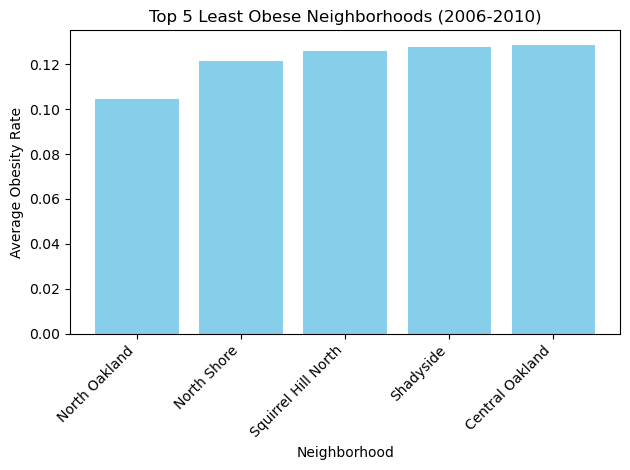

In [3]:
import matplotlib.pyplot as plt

least_obese = neighborhood_obesity.sort_values(by='Average Obesity Rate').head(5)

plt.bar(least_obese['Neighborhood'], least_obese['Average Obesity Rate'], color='skyblue')
plt.xlabel('Neighborhood')
plt.ylabel('Average Obesity Rate')
plt.title('Top 5 Least Obese Neighborhoods (2006-2010)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()


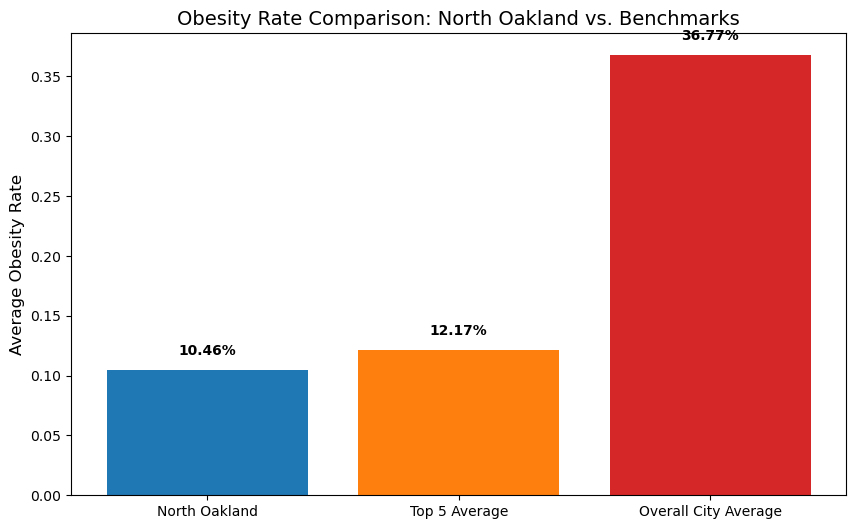

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('obesity-ac-2006-2010censustracts.csv')
neighborhood_stats = df.dropna(subset=['City Neighborhood']).groupby('City Neighborhood')['2006-2010 estimate of obesity'].mean().reset_index()
neighborhood_stats.columns = ['Neighborhood', 'Obesity Rate']

# 2. Calculate the specific comparison values

# North Oakland Average Obesity Rate
north_oak_rate = neighborhood_stats[neighborhood_stats['Neighborhood'].str.lower() == 'north oakland']['Obesity Rate'].values[0]

# Top 5 Least Obese Neighborhood Average Obesity Rate
top_5_avg = neighborhood_stats.sort_values(by='Obesity Rate').head(5)['Obesity Rate'].mean()

# Allegheny County Average Obesity Rate
total_avg = neighborhood_stats['Obesity Rate'].mean()


labels = ['North Oakland', 'Top 5 Average', 'Overall City Average']
values = [north_oak_rate, top_5_avg, total_avg]
colors = ['#1f77b4', '#ff7f0e', '#d62728'] # Blue, Orange, Red

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, values, color=colors)

plt.title('Obesity Rate Comparison: North Oakland vs. Benchmarks', fontsize=14)
plt.ylabel('Average Obesity Rate', fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', 
             ha='center', va='bottom', fontweight='bold')

plt.show()

In [16]:
# Load and prepare data
df = pd.read_csv('obesity-ac-2006-2010censustracts.csv')
neighborhood_stats = df.dropna(subset=['City Neighborhood']).groupby('City Neighborhood')['2006-2010 estimate of obesity'].mean().reset_index()
neighborhood_stats.columns = ['Neighborhood', 'Obesity Rate']

# 1. Get North Oakland's rate
north_oak_rate = neighborhood_stats[neighborhood_stats['Neighborhood'].str.lower() == 'north oakland']['Obesity Rate'].values[0]

# 2. Get average of top 5 healthiest (lowest obesity) neighborhoods
top_5_avg = neighborhood_stats.sort_values(by='Obesity Rate').head(5)['Obesity Rate'].mean()

# 3. Get average of all neighborhoods in the dataset
total_avg = neighborhood_stats['Obesity Rate'].mean()

# Calculate differences in percentage points
diff_top_5_pp = (north_oak_rate - top_5_avg) * 100
diff_city_avg_pp = (north_oak_rate - total_avg) * 100

# Output the results
print("-" * 35)
print(f"Diff (vs. Top 5):         {diff_top_5_pp:.2f} percentage points")
print(f"Diff (vs. City Avg):      {diff_city_avg_pp:.2f} percentage points")

-----------------------------------
Diff (vs. Top 5):         -1.71 percentage points
Diff (vs. City Avg):      -26.31 percentage points


* Conclusion - Why North Oakland Wins Based on obesity data-driven analysis: North Oakland is the best neighborhood in Pittsburgh. With an obesity rate of only 10.46%, it is a massive outlier compared to the city-wide average of 36.77%. North Oakland’s success isn't a coincidence. As a hub for universities like Pitt and CMU, it features: 
    - Extreme Walkability: Residents can commute, shop, and socialize entirely on foot.
    - Infrastructure: Proximity to Schenley Park provides immediate access to active recreation.
    - Food Access: The density of the area supports multiple grocery stores and diverse dining options that are often healthier than fast-food-heavy suburbs.
